# Alternative Data Phase Test v3 — All 8 Sources (Fixed)

**10 experiments** with BiGRU using Optuna-tuned hyperparameters from working classification pipeline.

**Key fix**: `weight_decay=1.8e-5` (from Optuna), NOT 0.02 (default). Default regularization
kills the model — sigmoid outputs constant 0.50 for every sample.

| # | Data Source | Dimension |
|---|-----------|----------|
| 1 | FRED-MD (baseline) | Macroeconomic |
| 2 | Technical Indicators | Price microstructure |
| 3 | CFTC COT | Market positioning |
| 4 | Cross-Commodity | Demand dynamics |
| 5 | Google Trends | Public attention |
| 6 | Weather (KS + ND) | Supply / growing conditions |
| 7 | VIX + OVX | Market fear / sentiment |
| 8 | NASA POWER | Vegetation / climate proxy |

In [3]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except: pass

if IN_COLAB:
    BASE_DIR = '/content/drive/MyDrive/Quants '
    QUANTS_DIR = BASE_DIR
else:
    BASE_DIR = '/Users/np3129/Documents/AI_ML_Quants_VIP'
    QUANTS_DIR = os.path.join(BASE_DIR, 'Quants data', 'Quants ')

ALT = os.path.join(BASE_DIR, 'alternative_data', 'raw')

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Bidirectional, GRU, Dense,
                                     GlobalAveragePooling1D, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# === Optuna-tuned hyperparameters from working BiGRU classification ===
HIDDEN = 128
NUM_LAYERS = 3
WD = 1.8e-5      # CRITICAL: default 0.02 kills the model
DO = 0.37
LR = 2.8e-4
EPOCHS = 50
BATCH = 64
LB = 30

print(f'Running on: {"Colab" if IN_COLAB else "Local"}')
print(f'Hyperparams: hidden={HIDDEN}, layers={NUM_LAYERS}, wd={WD}, do={DO}, lr={LR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on: Colab
Hyperparams: hidden=128, layers=3, wd=1.8e-05, do=0.37, lr=0.00028


## 1. Load All Data

In [4]:
# === WHEAT ===
inv = os.path.join(QUANTS_DIR, 'Investing.com')
pf = sorted([f for f in os.listdir(inv) if f.endswith('.csv') and 'Wheat' in f])
wheat = pd.concat([pd.read_csv(os.path.join(inv,f)) for f in pf], ignore_index=True)
wheat['Date'] = pd.to_datetime(wheat['Date'], format='mixed', dayfirst=False)
wheat = wheat.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)
for c in ['Price','Open','High','Low']:
    wheat[c] = pd.to_numeric(wheat[c].astype(str).str.replace(',',''), errors='coerce')
def pvol(v):
    v=str(v).strip().replace(',','')
    if v.endswith('K'): return float(v[:-1])*1000
    elif v.endswith('M'): return float(v[:-1])*1e6
    try: return float(v)
    except: return np.nan
wheat['Volume'] = wheat['Vol.'].apply(pvol)
wheat = wheat.dropna(subset=['Price']).reset_index(drop=True)
print(f'Wheat: {len(wheat)} days')

Wheat: 6864 days


In [5]:
# === FRED-MD ===
FF = ['RPI','W875RX1','CMRMTSPLx','IPFPNSS','USWTRADE','USTRADE','BUSLOANS','CONSPI',
    'S&P 500','S&P PE ratio','FEDFUNDS','TB3MS','TB6MS','GS1','GS5','GS10','AAA','BAA',
    'TB3SMFFM','TB6SMFFM','T1YFFM','T5YFFM','T10YFFM','AAAFFM','BAAFFM',
    'EXSZUSx','EXJPUSx','EXUSUKx','EXCAUSx','PPICMM','UMCSENTx']
fr = pd.read_csv(os.path.join(QUANTS_DIR,'FredMD_Dataset','2025-10-MD.csv'))
tc = fr.iloc[0]; fd = fr.iloc[1:].copy()
fd['sasdate'] = pd.to_datetime(fd['sasdate']); fd = fd.rename(columns={'sasdate':'Date'})
av = [f for f in FF if f in fd.columns]; fd = fd[['Date']+av].copy()
for c in av: fd[c] = pd.to_numeric(fd[c], errors='coerce')
tm = {}
for f in av:
    try: tm[f] = int(float(tc.get(f,1)))
    except: tm[f] = 1
def atc(s,t):
    if t==1: return s
    elif t==2: return s.diff()
    elif t==3: return s.diff().diff()
    elif t==4: return np.log(s.clip(lower=1e-10))
    elif t==5: return np.log(s.clip(lower=1e-10)).diff()
    elif t==6: return np.log(s.clip(lower=1e-10)).diff().diff()
    return s
for c in av: fd[c] = atc(fd[c], tm[c])
fd = fd.dropna().reset_index(drop=True)
fd['Date'] = fd['Date'] + pd.DateOffset(months=1)
fred_daily = fd.set_index('Date').resample('D').ffill().reset_index()
fred_cols = [c for c in fred_daily.columns if c!='Date']
print(f'FRED-MD: {len(fred_cols)} features')

FRED-MD: 31 features


In [6]:
# === TECHNICAL INDICATORS ===
def comp_tech(df):
    o = pd.DataFrame(index=df.index)
    c,h,l,v = df['Price'],df['High'],df['Low'],df['Volume'].fillna(0)
    for n in [5,10,20]: o[f'mom_{n}d'] = c.pct_change(n)
    d=c.diff(); g=d.clip(lower=0); lo=(-d).clip(lower=0)
    o['rsi']=100-(100/(1+g.rolling(14).mean()/lo.rolling(14).mean().replace(0,np.nan)))
    e12,e26=c.ewm(span=12).mean(),c.ewm(span=26).mean()
    macd=e12-e26; o['macd']=macd; o['macd_hist']=macd-macd.ewm(span=9).mean()
    s20,st20=c.rolling(20).mean(),c.rolling(20).std()
    o['bb_pctb']=(c-(s20-2*st20))/(4*st20).replace(0,np.nan)
    tr=pd.concat([h-l,(h-c.shift(1)).abs(),(l-c.shift(1)).abs()],axis=1).max(axis=1)
    o['atr']=tr.rolling(14).mean()
    o['vol_sma']=v/v.rolling(20).mean().replace(0,np.nan)
    return o
tech = comp_tech(wheat); tech_cols = tech.columns.tolist()
wheat = pd.concat([wheat, tech], axis=1)
print(f'Tech: {tech_cols}')

Tech: ['mom_5d', 'mom_10d', 'mom_20d', 'rsi', 'macd', 'macd_hist', 'bb_pctb', 'atr', 'vol_sma']


In [7]:
# === COT ===
cr = pd.read_csv(os.path.join(ALT,'cot_wheat_disaggregated.csv'))
cr['Date'] = pd.to_datetime(cr['Report_Date_as_YYYY-MM-DD'])
nc=['Open_Interest_All','Prod_Merc_Positions_Long_All','Prod_Merc_Positions_Short_All',
    'M_Money_Positions_Long_All','M_Money_Positions_Short_All']
for c in nc: cr[c]=pd.to_numeric(cr[c],errors='coerce')
cot=cr.groupby('Date')[nc].sum().reset_index()
oi=cot['Open_Interest_All'].replace(0,np.nan)
cot['mm_net']=cot['M_Money_Positions_Long_All']-cot['M_Money_Positions_Short_All']
cot['cm_net']=cot['Prod_Merc_Positions_Long_All']-cot['Prod_Merc_Positions_Short_All']
cot['hedge_pr']=cot['cm_net']/oi; cot['spec_se']=cot['mm_net']/oi
cot['pos_chg']=cot['mm_net'].diff(4)
cot['spec_z']=(cot['mm_net']-cot['mm_net'].rolling(52).mean())/cot['mm_net'].rolling(52).std().replace(0,np.nan)
cot['oi_lev']=cot['Open_Interest_All']
cot_features=['hedge_pr','spec_se','pos_chg','spec_z','oi_lev']
cot['Date']=cot['Date']+pd.Timedelta(days=3)
cot_d=cot[['Date']+cot_features].set_index('Date').resample('D').ffill().reset_index()
print(f'COT: {len(cot_d)} rows')

COT: 4740 rows


In [8]:
# === CROSS-COMMODITY ===
ca={'corn_futures.csv':'corn','soybean_futures.csv':'soy','crude_oil_wti.csv':'oil',
    'usd_index.csv':'usd','gold_futures.csv':'gold'}
cdfs=[]
for fn,lb in ca.items():
    d=pd.read_csv(os.path.join(ALT,fn),header=[0,1],index_col=0,parse_dates=True)
    d.columns=[c[0] for c in d.columns]; d=d.reset_index()
    d['Date']=pd.to_datetime(d['Date']); d[f'{lb}_cl']=pd.to_numeric(d['Close'],errors='coerce')
    cdfs.append(d[['Date',f'{lb}_cl']].dropna())
xc=cdfs[0]
for d in cdfs[1:]: xc=pd.merge(xc,d,on='Date',how='outer')
xc=xc.sort_values('Date').ffill().dropna().reset_index(drop=True)
xc=pd.merge(xc,wheat[['Date','Price']].rename(columns={'Price':'w_cl'}),on='Date',how='inner')
xc['wc_rat']=xc['w_cl']/xc['corn_cl'].replace(0,np.nan)
xc['ws_rat']=xc['w_cl']/xc['soy_cl'].replace(0,np.nan)
xc['wc_m20']=xc['wc_rat'].pct_change(20); xc['ws_m20']=xc['ws_rat'].pct_change(20)
wr=xc['w_cl'].pct_change(10)
xc['rel_cn']=wr-xc['corn_cl'].pct_change(10); xc['rel_ol']=wr-xc['oil_cl'].pct_change(10)
xc['usd_c10']=xc['usd_cl'].pct_change(10); xc['gld_c10']=xc['gold_cl'].pct_change(10)
cross_fcols=['wc_rat','ws_rat','wc_m20','ws_m20','rel_cn','rel_ol','usd_c10','gld_c10']
xc=xc.drop(columns=['w_cl'])
print(f'Cross: {len(xc)} rows')

Cross: 4514 rows


In [9]:
# === GOOGLE TRENDS + WEATHER + VIX/OVX + NASA ===
gt=pd.read_csv(os.path.join(ALT,'google_trends.csv')); gt['Date']=pd.to_datetime(gt['Date'])
gt_cols=[c for c in gt.columns if c!='Date' and c!='isPartial']; gt=gt[['Date']+gt_cols]
gt_d=gt.set_index('Date').resample('D').ffill().reset_index()
print(f'Trends: {len(gt_d)} rows, {gt_cols}')

wk=pd.read_csv(os.path.join(ALT,'weather_kansas.csv')); wk['Date']=pd.to_datetime(wk['Date'])
wnd=pd.read_csv(os.path.join(ALT,'weather_north_dakota.csv')); wnd['Date']=pd.to_datetime(wnd['Date'])
weather=pd.merge(wk,wnd,on='Date',how='outer').sort_values('Date').ffill().dropna()
weather_cols=[c for c in weather.columns if c!='Date']
print(f'Weather: {len(weather)} rows, {len(weather_cols)} features')

vix=pd.read_csv(os.path.join(ALT,'vix.csv')); vix['Date']=pd.to_datetime(vix['Date'])
ovx=pd.read_csv(os.path.join(ALT,'ovx.csv')); ovx['Date']=pd.to_datetime(ovx['Date'])
fear=pd.merge(vix,ovx,on='Date',how='outer').sort_values('Date').ffill().dropna()
fear_cols=['vix_close','ovx_close']
print(f'VIX/OVX: {len(fear)} rows')

nasa=pd.read_csv(os.path.join(ALT,'nasa_power_ag.csv')); nasa['Date']=pd.to_datetime(nasa['Date'])
nasa_cols=[c for c in nasa.columns if c!='Date']; nasa=nasa.dropna()
print(f'NASA: {len(nasa)} rows')

Trends: 5814 rows, ['wheat_price', 'wheat_futures', 'drought', 'crop_failure', 'USDA_report']
Weather: 5844 rows, 12 features
VIX/OVX: 4528 rows
NASA: 5844 rows


## 2. Merge & Prepare

In [10]:
master = wheat[['Date','Price']+tech_cols].copy().sort_values('Date')
master = pd.merge_asof(master, fred_daily.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, cot_d.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, xc[['Date']+cross_fcols].sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, gt_d.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, weather.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, fear.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, nasa.sort_values('Date'), on='Date', direction='backward')
master = master[master['Date']>='2013-06-01'].reset_index(drop=True)
master = master.ffill().bfill().replace([np.inf,-np.inf],np.nan).dropna().reset_index(drop=True)

print(f'Master: {master.shape}')
print(f'Range: {master["Date"].min().date()} to {master["Date"].max().date()}')

Master: (3204, 81)
Range: 2013-06-03 to 2025-12-12


## 3. Define Experiments

In [11]:
base = fred_cols + ['Price']
EXPERIMENTS = {
    '1. Baseline (FRED+Price)':    base,
    '2. +Tech Indicators':         base + tech_cols,
    '3. +COT':                     base + cot_features,
    '4. +Cross-Commodity':         base + cross_fcols,
    '5. +Google Trends':           base + gt_cols,
    '6. +Weather':                 base + weather_cols,
    '7. +VIX/OVX (Fear)':         base + fear_cols,
    '8. +NASA Ag':                 base + nasa_cols,
    '9. Tech+COT+Cross':          base + tech_cols + cot_features + cross_fcols,
    '10. ALL COMBINED':            base + tech_cols + cot_features + cross_fcols + gt_cols + weather_cols + fear_cols + nasa_cols,
}
for name, feats in EXPERIMENTS.items():
    print(f'{name:30s} -> {len(feats)} features')

1. Baseline (FRED+Price)       -> 32 features
2. +Tech Indicators            -> 41 features
3. +COT                        -> 37 features
4. +Cross-Commodity            -> 40 features
5. +Google Trends              -> 37 features
6. +Weather                    -> 44 features
7. +VIX/OVX (Fear)             -> 34 features
8. +NASA Ag                    -> 39 features
9. Tech+COT+Cross              -> 54 features
10. ALL COMBINED               -> 80 features


## 4. Model & Runner

In [12]:
def create_windows(df, fcols, lb=30):
    """Target = price[t] > price[t-1], computed inside loop (matches working pipeline)."""
    data = df[fcols].values; price = df['Price'].values
    X, y = [], []
    for i in range(lb, len(data)):
        X.append(data[i-lb:i])
        y.append(1 if price[i] > price[i-1] else 0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def scale_3d(Xtr, Xte):
    """Flatten (N,30,F) -> (N,30*F), scale, reshape back (matches working pipeline)."""
    n,lb,nf = Xtr.shape
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr.reshape(n, lb*nf)).reshape(n, lb, nf)
    Xte_s = sc.transform(Xte.reshape(Xte.shape[0], lb*nf)).reshape(Xte.shape[0], lb, nf)
    return Xtr_s, Xte_s

def build_model(sl, nf):
    """BiGRU with Optuna-tuned hyperparams from working classification notebook."""
    inp = Input(shape=(sl, nf))
    x = inp
    for _ in range(NUM_LAYERS):
        x = Bidirectional(GRU(HIDDEN, return_sequences=True, dropout=DO,
                              kernel_regularizer=l2(WD)))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(DO)(x)
    out = Dense(1, activation='sigmoid', kernel_regularizer=l2(WD))(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

def run_experiment(name, fcols, master_df):
    print(f'\n{"="*55}')
    print(f'  {name} ({len(fcols)} features)')
    print(f'{"="*55}')
    X, y = create_windows(master_df, fcols, LB)
    sp = int(len(X) * 0.8)
    Xtr, ytr = X[:sp], y[:sp]
    Xte, yte = X[sp:], y[sp:]
    Xtr_s, Xte_s = scale_3d(Xtr, Xte)
    print(f'  Train: {Xtr_s.shape}, Test: {Xte_s.shape}')
    print(f'  Train Up: {ytr.mean():.1%}, Test Up: {yte.mean():.1%}')
    cw = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr)
    tf.keras.backend.clear_session()
    model = build_model(LB, len(fcols))
    model.fit(Xtr_s, ytr, epochs=EPOCHS, batch_size=BATCH, shuffle=False,
              class_weight={0:cw[0], 1:cw[1]}, verbose=0,
              callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True),
                         ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)])
    yp = model.predict(Xte_s, verbose=0).ravel()
    ypd = (yp >= 0.5).astype(int)
    r = {'Experiment': name, 'Features': len(fcols),
         'Accuracy': accuracy_score(yte, ypd),
         'Precision': precision_score(yte, ypd, zero_division=0),
         'Recall': recall_score(yte, ypd, zero_division=0),
         'F1': f1_score(yte, ypd, zero_division=0),
         'AUC-ROC': roc_auc_score(yte, yp)}
    print(f'  Acc={r["Accuracy"]:.4f}  F1={r["F1"]:.4f}  AUC={r["AUC-ROC"]:.4f}  P={r["Precision"]:.4f}  R={r["Recall"]:.4f}')
    print(f'  Pred >0.5: {(yp>0.5).sum()}/{len(yp)}  <0.5: {(yp<0.5).sum()}/{len(yp)}')
    return r, yte, ypd, yp

## 5. Run ALL 10 Experiments

In [13]:
all_results = []
all_preds = {}
for name, fcols in EXPERIMENTS.items():
    r, yte, ypred, yprob = run_experiment(name, fcols, master)
    all_results.append(r)
    all_preds[name] = {'y_test': yte, 'y_pred': ypred, 'y_prob': yprob}
print('\n\nAll 10 experiments complete!')


  1. Baseline (FRED+Price) (32 features)
  Train: (2539, 30, 32), Test: (635, 30, 32)
  Train Up: 47.5%, Test Up: 46.3%
  Acc=0.4661  F1=0.6271  AUC=0.4829  P=0.4634  R=0.9694
  Pred >0.5: 615/635  <0.5: 20/635

  2. +Tech Indicators (41 features)
  Train: (2539, 30, 41), Test: (635, 30, 41)
  Train Up: 47.5%, Test Up: 46.3%
  Acc=0.4819  F1=0.6205  AUC=0.5468  P=0.4695  R=0.9150
  Pred >0.5: 573/635  <0.5: 62/635

  3. +COT (37 features)
  Train: (2539, 30, 37), Test: (635, 30, 37)
  Train Up: 47.5%, Test Up: 46.3%
  Acc=0.4945  F1=0.5008  AUC=0.4999  P=0.4613  R=0.5476
  Pred >0.5: 349/635  <0.5: 286/635

  4. +Cross-Commodity (40 features)
  Train: (2539, 30, 40), Test: (635, 30, 40)
  Train Up: 47.5%, Test Up: 46.3%
  Acc=0.4866  F1=0.5842  AUC=0.5291  P=0.4673  R=0.7789
  Pred >0.5: 490/635  <0.5: 145/635

  5. +Google Trends (37 features)
  Train: (2539, 30, 37), Test: (635, 30, 37)
  Train Up: 47.5%, Test Up: 46.3%
  Acc=0.4929  F1=0.5439  AUC=0.4911  P=0.4660  R=0.6531
  Pred 

## 6. Results

In [14]:
results_df = pd.DataFrame(all_results).set_index('Experiment')
print('='*75)
print('RESULTS — Which Alternative Data Helps Most?')
print('='*75)
print(results_df.to_string(float_format='{:.4f}'.format))
print()
print(f'Best Accuracy: {results_df["Accuracy"].idxmax()} ({results_df["Accuracy"].max():.4f})')
print(f'Best AUC-ROC:  {results_df["AUC-ROC"].idxmax()} ({results_df["AUC-ROC"].max():.4f})')
print(f'Best F1:       {results_df["F1"].idxmax()} ({results_df["F1"].max():.4f})')

RESULTS — Which Alternative Data Helps Most?
                          Features  Accuracy  Precision  Recall     F1  AUC-ROC
Experiment                                                                     
1. Baseline (FRED+Price)        32    0.4661     0.4634  0.9694 0.6271   0.4829
2. +Tech Indicators             41    0.4819     0.4695  0.9150 0.6205   0.5468
3. +COT                         37    0.4945     0.4613  0.5476 0.5008   0.4999
4. +Cross-Commodity             40    0.4866     0.4673  0.7789 0.5842   0.5291
5. +Google Trends               37    0.4929     0.4660  0.6531 0.5439   0.4911
6. +Weather                     44    0.4661     0.4551  0.7755 0.5736   0.4994
7. +VIX/OVX (Fear)              34    0.4772     0.4657  0.8776 0.6085   0.5033
8. +NASA Ag                     39    0.4740     0.4642  0.8810 0.6080   0.4926
9. Tech+COT+Cross               54    0.5449     0.5217  0.2041 0.2934   0.5237
10. ALL COMBINED                80    0.4992     0.4745  0.7585 0.5838   0.

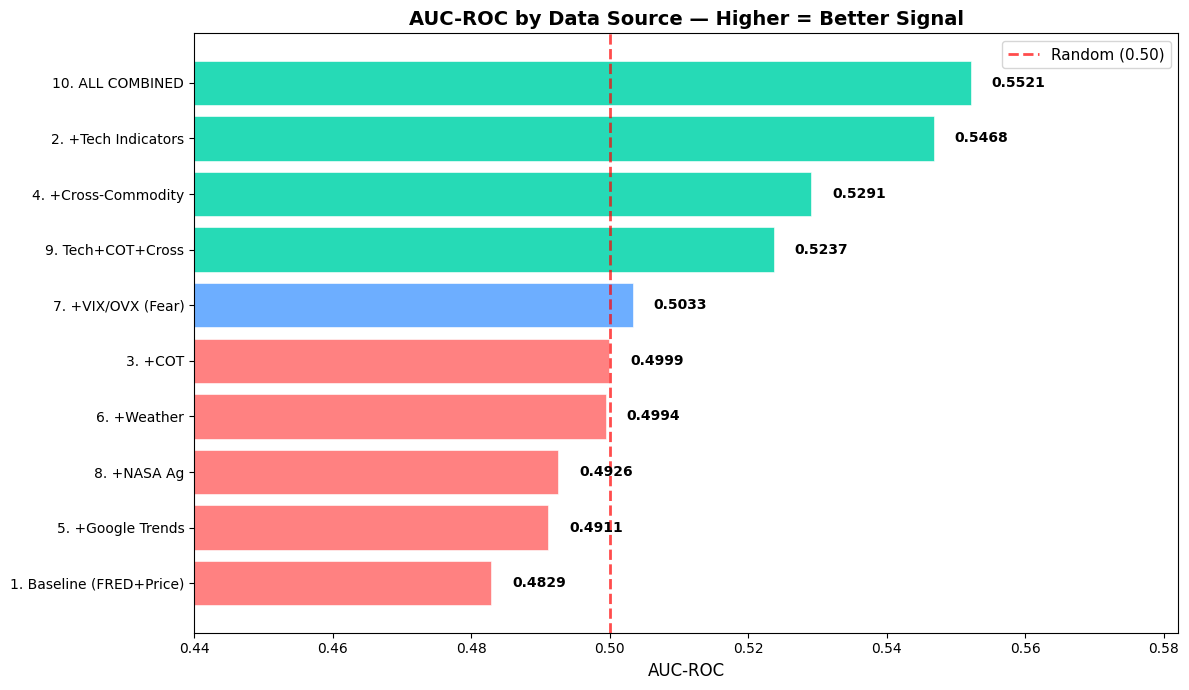

In [15]:
# AUC-ROC bar chart
fig, ax = plt.subplots(figsize=(12, 7))
vals = results_df['AUC-ROC'].sort_values()
colors = ['#FF6B6B' if v<0.5 else '#54A0FF' if v<0.52 else '#00D4AA' for v in vals.values]
bars = ax.barh(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Random (0.50)', linewidth=2)
for bar, val in zip(bars, vals.values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('AUC-ROC', fontsize=12)
ax.set_title('AUC-ROC by Data Source — Higher = Better Signal', fontsize=14, fontweight='bold')
ax.set_xlim(0.44, max(0.58, vals.max()+0.03))
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

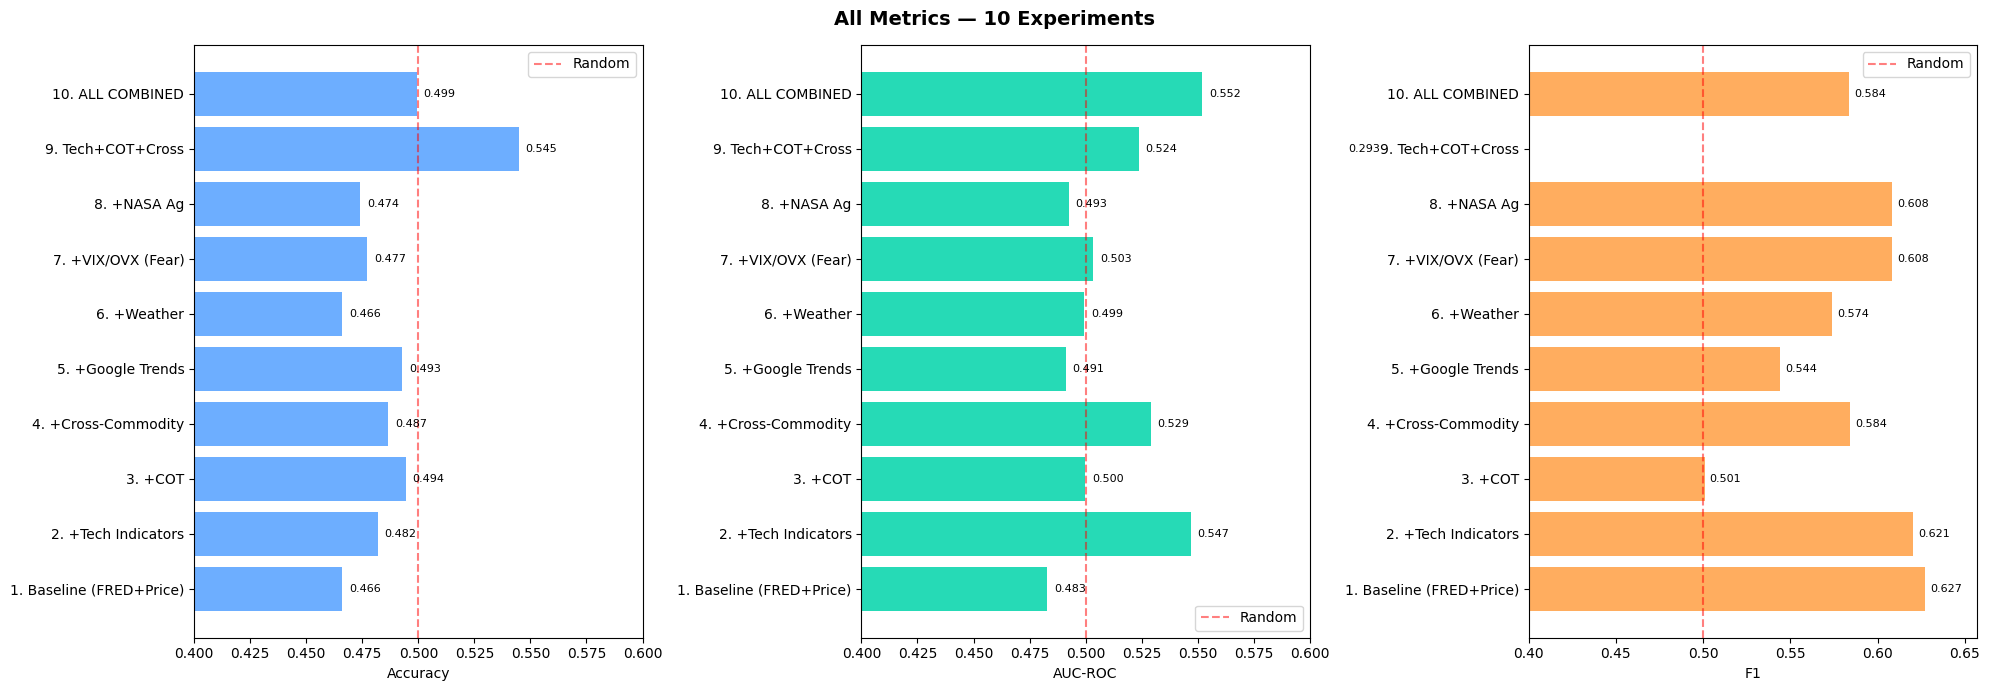

In [16]:
# All 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, metric, color in zip(axes, ['Accuracy','AUC-ROC','F1'], ['#54A0FF','#00D4AA','#FF9F43']):
    vals = results_df[metric]
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.85)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    ax.set_xlabel(metric); ax.legend()
    ax.set_xlim(0.40, max(0.60, vals.max()+0.03))
    for bar, val in zip(bars, vals.values):
        ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
fig.suptitle('All Metrics — 10 Experiments', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

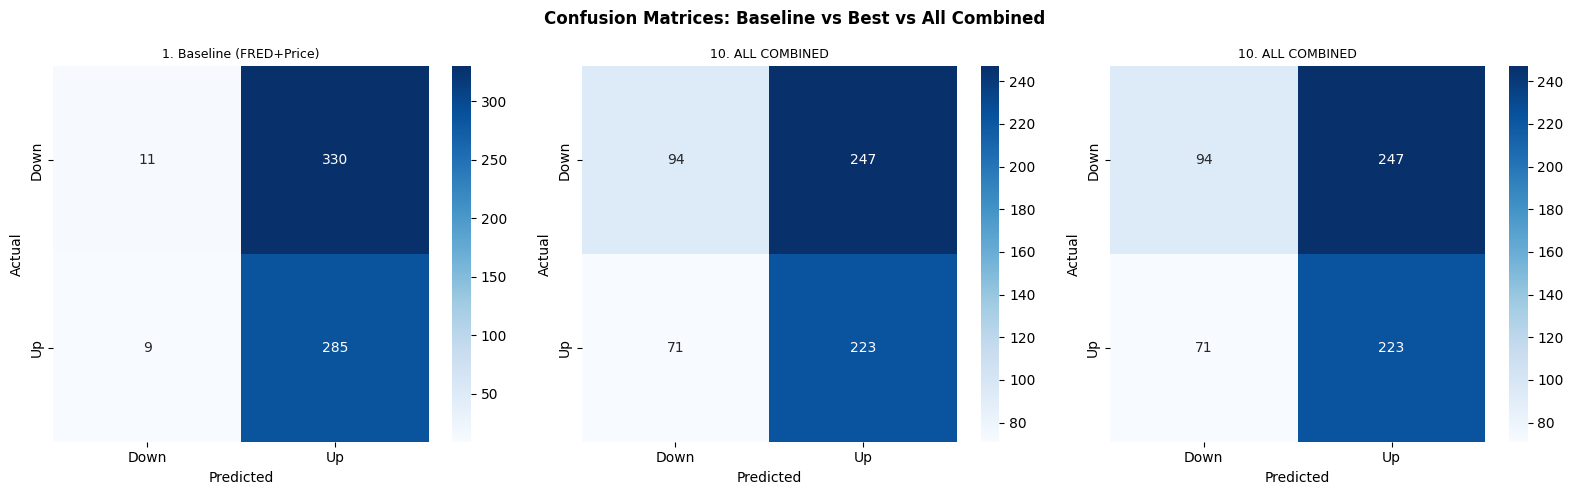

In [17]:
# Confusion matrices
best_name = results_df['AUC-ROC'].idxmax()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, ['1. Baseline (FRED+Price)', best_name, '10. ALL COMBINED']):
    p = all_preds[name]
    cm = confusion_matrix(p['y_test'], p['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_title(name, fontsize=9); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices: Baseline vs Best vs All Combined', fontweight='bold')
plt.tight_layout(); plt.show()

In [18]:
out_path = os.path.join(BASE_DIR, 'alternative_data', 'processed', 'phase_test_v3_results.csv')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
results_df.to_csv(out_path)
print(f'Results saved to: {out_path}')
print()
bl_auc = results_df.loc['1. Baseline (FRED+Price)', 'AUC-ROC']
all_auc = results_df.loc['10. ALL COMBINED', 'AUC-ROC']
best_auc = results_df['AUC-ROC'].max()
print(f'Baseline AUC:     {bl_auc:.4f}')
print(f'Best single AUC:  {best_auc:.4f} ({results_df["AUC-ROC"].idxmax()})')
print(f'ALL COMBINED AUC: {all_auc:.4f}')
print(f'ALL COMBINED Acc: {results_df.loc["10. ALL COMBINED", "Accuracy"]:.4f}')

Results saved to: /content/drive/MyDrive/Quants /alternative_data/processed/phase_test_v3_results.csv

Baseline AUC:     0.4829
Best single AUC:  0.5521 (10. ALL COMBINED)
ALL COMBINED AUC: 0.5521
ALL COMBINED Acc: 0.4992
